In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv("sales_data.csv")
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,NaN,NaN,Grocery Store,732.3800,13.6
4,NCD19,8.93,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7774 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       6473 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  Profit                     8523 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage:

In [4]:
num_data=data.select_dtypes(include=np.number)
num_data

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
0,9.300,0.016047,249.8,1999,3735.1380,11.5
1,5.920,0.019278,48.3,2009,443.4228,14.3
2,17.500,0.016760,141.6,1999,2097.2700,14.5
3,19.200,0.000000,182.1,1998,732.3800,13.6
4,8.930,0.000000,53.9,1987,994.7052,14.1
...,...,...,...,...,...,...
8518,6.865,0.056783,214.5,1987,2778.3834,14.1
8519,8.380,0.046982,108.2,2002,549.2850,14.2
8520,10.600,0.035186,85.1,2004,1193.1136,9.5
8521,7.210,0.145221,103.1,2009,1845.5976,14.2


In [6]:
cat_data=data.select_dtypes(exclude=np.number)
cat_data

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 2,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 2,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 2,Supermarket Type1
3,FDX07,Regular,Fruits and Vegetables,OUT010,NaN,NaN,Grocery Store
4,NCD19,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1
...,...,...,...,...,...,...,...
8518,FDF22,Low Fat,Snack Foods,OUT013,High,Tier 3,Supermarket Type1
8519,FDS36,Regular,Baking Goods,OUT045,NaN,NaN,Supermarket Type1
8520,NCJ29,Low Fat,Health and Hygiene,OUT035,Small,Tier1,Supermarket Type1
8521,FDN46,Regular,Snack Foods,OUT018,Medium,Tier 2,Supermarket Type2


In [7]:
#central tendency---->mean,median,mode,quantile,covarinve,correlation

In [8]:
#mean
num_data.mean()

Item_Weight                    11.676740
Item_Visibility                 0.066132
Item_MRP                      140.998838
Outlet_Establishment_Year    1997.831867
Item_Outlet_Sales            2181.288914
Profit                         13.414514
dtype: float64

In [ ]:
# The Avg sale value generated by selling the items across all the outlet is Rs.2181

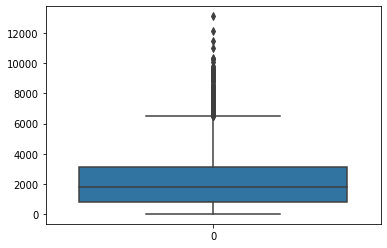

In [9]:
sns.boxplot(num_data["Item_Outlet_Sales"])
plt.show()

In [11]:
check=pd.Series([10,5,18,25,56,1000,750])
print(check.mean())
print(check.median())

266.2857142857143
25.0


In [12]:
num_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
count,7774.000000,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,11.676740,0.066132,140.998838,1997.831867,2181.288914,13.414514
std,5.776851,0.051598,62.258099,8.371760,1706.499616,1.701840
min,0.000000,0.000000,31.300000,1985.000000,33.290000,0.100000
25%,7.720000,0.026989,93.800000,1987.000000,834.247400,13.150000
50%,11.800000,0.053931,142.700000,1999.000000,1794.331000,13.900000
75%,16.500000,0.094585,185.650000,2004.000000,3101.296400,14.300000
max,21.350000,0.328391,266.900000,2009.000000,13086.964800,24.000000


<AxesSubplot: >

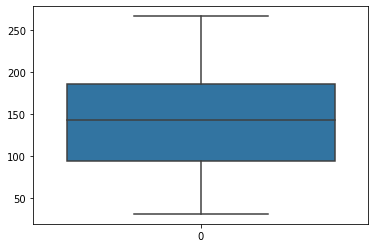

In [13]:
sns.boxplot(num_data["Item_MRP"])

<AxesSubplot: >

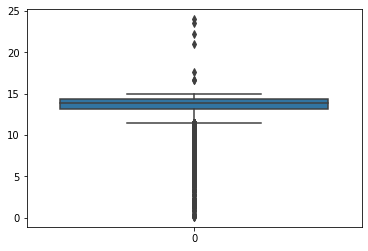

In [14]:
sns.boxplot(num_data["Profit"])

In [21]:
#trimmed mean
import scipy.stats as stats
stats.trim_mean(num_data["Item_Outlet_Sales"],proportiontocut=0.1)

1971.326787710808

In [22]:
res=pd.DataFrame()
res["Mean"]=num_data.mean()
res["Median"]=num_data.median()
res["trimmed_mean"]=stats.trim_mean(num_data,proportiontocut=0.1)
res

,Mean,Median,trimmed_mean
Item_Weight,11.676740,11.800000,12.892137
Item_Visibility,0.066132,0.053931,0.060344
Item_MRP,140.998838,142.700000,139.706731
Outlet_Establishment_Year,1997.831867,1999.000000,1998.039742
Item_Outlet_Sales,2181.288914,1794.331000,1971.326788
Profit,13.414514,13.900000,13.744640


In [28]:
#quantile
per=num_data.quantile([0.1,0.2,0.4,0.5,0.7,0.9]).T
per

,0.1,0.2,0.4,0.5,0.7,0.9
Item_Weight,5.110000,6.983000,10.000000,11.800000,15.600000,19.250000
Item_Visibility,0.012042,0.022558,0.041754,0.053931,0.083456,0.139514
Item_MRP,52.800000,84.700000,118.880000,142.700000,177.800000,231.200000
Outlet_Establishment_Year,1985.000000,1987.000000,1998.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,343.552800,666.465800,1402.174800,1794.331000,2805.814360,4570.051200
Profit,11.800000,12.900000,13.700000,13.900000,14.300000,14.600000


In [38]:
res=pd.concat([res,per],axis=1)

In [35]:
#How much percentage of data in profit is less than 6?
num_data["Profit"].quantile(0.01)

5.7

In [36]:
num_data[num_data["Profit"]<5.7]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
217,13.65,0.134976,260.1,1998,260.9936,3.2
320,0.00,0.042087,122.4,1985,5448.9072,0.2
457,20.25,0.102724,93.2,1997,1957.4520,2.7
602,20.85,0.000000,115.2,2009,1054.6272,1.7
716,17.35,0.146896,149.6,2009,3745.1250,5.2
...,...,...,...,...,...,...
7948,9.30,0.042531,125.5,2007,2848.2924,5.3
8074,15.60,0.045056,242.4,1999,2416.8540,0.2
8099,0.00,0.138777,147.5,1985,5219.8720,4.1
8429,19.75,0.018020,181.6,2004,2876.2560,4.1


In [39]:
# Measure of dispersion/deviation--->Range,variance,standard Deviation,iqr,coeff of variance

#range-->max-min
res["range"]=num_data.max()-num_data.min()
res

,Mean,Median,trimmed_mean,range,0.1,0.2,0.4,0.5,0.7,0.9
Item_Weight,11.676740,11.800000,12.892137,21.350000,5.110000,6.983000,10.000000,11.800000,15.600000,19.250000
Item_Visibility,0.066132,0.053931,0.060344,0.328391,0.012042,0.022558,0.041754,0.053931,0.083456,0.139514
Item_MRP,140.998838,142.700000,139.706731,235.600000,52.800000,84.700000,118.880000,142.700000,177.800000,231.200000
Outlet_Establishment_Year,1997.831867,1999.000000,1998.039742,24.000000,1985.000000,1987.000000,1998.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,2181.288914,1794.331000,1971.326788,13053.674800,343.552800,666.465800,1402.174800,1794.331000,2805.814360,4570.051200
Profit,13.414514,13.900000,13.744640,23.900000,11.800000,12.900000,13.700000,13.900000,14.300000,14.600000


In [40]:
#variance
num_data.var()

Item_Weight                  3.337201e+01
Item_Visibility              2.662335e-03
Item_MRP                     3.876071e+03
Outlet_Establishment_Year    7.008637e+01
Item_Outlet_Sales            2.912141e+06
Profit                       2.896258e+00
dtype: float64

In [41]:
num_data.std()

Item_Weight                     5.776851
Item_Visibility                 0.051598
Item_MRP                       62.258099
Outlet_Establishment_Year       8.371760
Item_Outlet_Sales            1706.499616
Profit                          1.701840
dtype: float64

In [ ]:
# best practice to define result with mean along with standard deviation

In [42]:
#coeff of variance--------->std/mean
num_data.std()/num_data.mean()

Item_Weight                  0.494732
Item_Visibility              0.780224
Item_MRP                     0.441550
Outlet_Establishment_Year    0.004190
Item_Outlet_Sales            0.782335
Profit                       0.126866
dtype: float64

In [43]:
# bivariant
#covariance and correlation

In [44]:
# covariance------->is there any relation between 2 vraibales(ile poitive or negative)
num_data.cov()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
Item_Weight,33.372008,-0.016030,7.425851,16.293339,-3.295708e+02,-0.160196
Item_Visibility,-0.016030,0.002662,-0.005131,-0.032325,-1.132561e+01,0.001253
Item_MRP,7.425851,-0.005131,3876.070885,2.629821,6.029901e+04,0.435364
Outlet_Establishment_Year,16.293339,-0.032325,2.629821,70.086372,-7.019621e+02,-0.280298
Item_Outlet_Sales,-329.570782,-11.325611,60299.006078,-701.962133,2.912141e+06,2.762921
Profit,-0.160196,0.001253,0.435364,-0.280298,2.762921e+00,2.896258


In [45]:
#correlation
num_data.corr()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
Item_Weight,1.000000,-0.055081,0.020616,0.365815,-0.034997,-0.016058
Item_Visibility,-0.055081,1.000000,-0.001597,-0.074834,-0.128625,0.014269
Item_MRP,0.020616,-0.001597,1.000000,0.005046,0.567555,0.004109
Outlet_Establishment_Year,0.365815,-0.074834,0.005046,1.000000,-0.049135,-0.019674
Item_Outlet_Sales,-0.034997,-0.128625,0.567555,-0.049135,1.000000,0.000951
Profit,-0.016058,0.014269,0.004109,-0.019674,0.000951,1.000000


In [46]:
num_data.corr(method="pearson")

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
Item_Weight,1.000000,-0.055081,0.020616,0.365815,-0.034997,-0.016058
Item_Visibility,-0.055081,1.000000,-0.001597,-0.074834,-0.128625,0.014269
Item_MRP,0.020616,-0.001597,1.000000,0.005046,0.567555,0.004109
Outlet_Establishment_Year,0.365815,-0.074834,0.005046,1.000000,-0.049135,-0.019674
Item_Outlet_Sales,-0.034997,-0.128625,0.567555,-0.049135,1.000000,0.000951
Profit,-0.016058,0.014269,0.004109,-0.019674,0.000951,1.000000


In [47]:
num_data.corr(method="spearman")

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
Item_Weight,1.000000,-0.031204,0.025524,0.244957,0.012541,-0.015293
Item_Visibility,-0.031204,1.000000,0.005339,-0.054924,-0.115076,-0.005699
Item_MRP,0.025524,0.005339,1.000000,0.003705,0.562981,0.005998
Outlet_Establishment_Year,0.244957,-0.054924,0.003705,1.000000,0.042947,-0.013878
Item_Outlet_Sales,0.012541,-0.115076,0.562981,0.042947,1.000000,0.018696
Profit,-0.015293,-0.005699,0.005998,-0.013878,0.018696,1.000000


In [48]:
#measure of distribution
#Skew,kurtosis
num_data.skew()

Item_Weight                 -0.352215
Item_Visibility              1.167091
Item_MRP                     0.127390
Outlet_Establishment_Year   -0.396641
Item_Outlet_Sales            1.177531
Profit                      -3.379808
dtype: float64

<AxesSubplot: xlabel='Item_Outlet_Sales', ylabel='Density'>

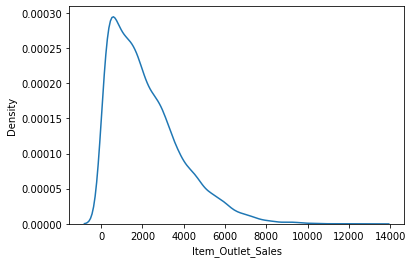

In [49]:
sns.distplot(num_data["Item_Outlet_Sales"],hist=False)


<AxesSubplot: xlabel='Profit', ylabel='Density'>

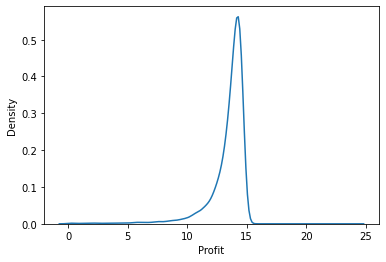

In [50]:
sns.distplot(num_data["Profit"],hist=False)

In [51]:
# transformation
# log
# sqrt
# power

<AxesSubplot: xlabel='Item_Outlet_Sales', ylabel='Density'>

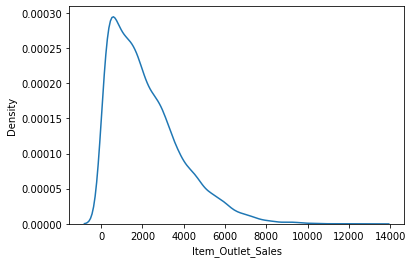

In [53]:
sns.distplot(num_data["Item_Outlet_Sales"],hist=False)


<AxesSubplot: ylabel='Density'>

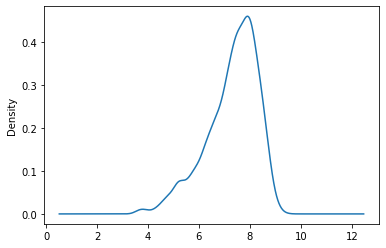

In [54]:
np.log(num_data["Item_Outlet_Sales"]).plot(kind="kde")

In [55]:
np.log(num_data["Item_Outlet_Sales"]).skew()

-0.8877533432093057

In [56]:
np.sqrt(num_data["Item_Outlet_Sales"]).skew()

0.23467599347099247

<AxesSubplot: ylabel='Density'>

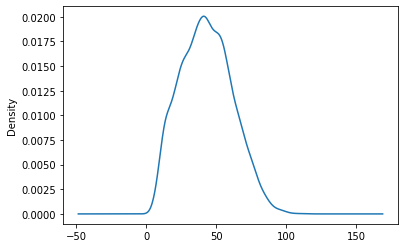

In [57]:
np.sqrt(num_data["Item_Outlet_Sales"]).plot(kind="kde")

In [58]:
num_data["Item_Outlet_Sales"].mean()

2181.288913575032

In [62]:
logdata=np.log(num_data["Item_Outlet_Sales"])

In [64]:
#np.exp(logdata).mean()

2181.288913575032